In [87]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from matplotlib.ticker import FuncFormatter

def format_currency():
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
    
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [66]:
# Read the csv

df = pd.read_csv(r'C:\Users\Amanda\Downloads\nvidia_gpu_sales_synthetic_2026.csv')
df

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6996,2026-06-28,RTX 5070,Consumer Gaming,2025,Europe,System Integrator/OEM,Content Creation,19,549,764.54,39.26,Backordered,3.5,24,NaN,14526.24
6996,6997,2026-06-28,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Content Creation,12,999,1354.06,35.54,Sold Out,3.5,12,Extended Warranty,16248.74
6997,6998,2026-06-28,RTX 5070,Consumer Gaming,2025,China,System Integrator/OEM,Gaming,49,549,558.18,1.67,In Stock,4.5,36,NaN,27350.88
6998,6999,2026-06-29,RTX 5070,Consumer Gaming,2025,Asia-Pacific (ex-China),Retail/Etail,Gaming,23,549,604.02,10.02,Low Stock,5.0,12,NaN,13892.52


In [67]:
# Look at data

df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56


In [68]:
# Check for missing data

for col in df.columns:
    missing = np.mean(df[col].isnull())
    print('{} = {}%'.format(col, missing))

sale_id = 0.0%
sale_date = 0.0%
gpu_model = 0.0%
gpu_family = 0.0%
launch_year = 0.0%
region = 0.0%
sales_channel = 0.0%
customer_segment = 0.0%
units_sold = 0.0%
msrp_usd = 0.0%
avg_street_price_usd = 0.0%
price_premium_pct = 0.0%
stock_status = 0.0%
customer_satisfaction_score = 0.0%
warranty_months = 0.0%
bundle_addon = 0.5487142857142857%
revenue_usd = 0.0%


In [69]:
# Check for duplicates

df['sale_id'].duplicated().sum()

np.int64(0)

In [70]:
# Check data types

print(df.dtypes)

sale_id                          int64
sale_date                       object
gpu_model                       object
gpu_family                      object
launch_year                      int64
region                          object
sales_channel                   object
customer_segment                object
units_sold                       int64
msrp_usd                         int64
avg_street_price_usd           float64
price_premium_pct              float64
stock_status                    object
customer_satisfaction_score    float64
warranty_months                  int64
bundle_addon                    object
revenue_usd                    float64
dtype: object


In [71]:
# Edit neccesary data types

df['sale_date'] = pd.to_datetime(df['sale_date'])

categorical_cols = ['gpu_family',
                    'region',
                    'sales_channel',
                    'customer_segment', 
                    'stock_status', 
                    'bundle_addon'
                   ]
for col in categorical_cols:
    df[col] = df[col].astype('category')

df['launch_year'] = df['launch_year'].astype('int16')
df['warranty_months'] = df['warranty_months'].astype('int8')
df['msrp_usd'] = df['msrp_usd'].astype('int32')
df['units_sold'] = df['units_sold'].astype('int32')

In [72]:
# Check data types again

print(df.dtypes)

sale_id                                 int64
sale_date                      datetime64[ns]
gpu_model                              object
gpu_family                           category
launch_year                             int16
region                               category
sales_channel                        category
customer_segment                     category
units_sold                              int32
msrp_usd                                int32
avg_street_price_usd                  float64
price_premium_pct                     float64
stock_status                         category
customer_satisfaction_score           float64
warranty_months                          int8
bundle_addon                         category
revenue_usd                           float64
dtype: object


In [73]:
# Derived columns / feature engineerng

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month_name()
df['revenue_per_unit'] = df['revenue_usd'] / df['units_sold']
df['gpu_age'] = df['sale_date'].dt.year - df['launch_year']

In [74]:
# Check data types again

print(df.dtypes)

sale_id                                 int64
sale_date                      datetime64[ns]
gpu_model                              object
gpu_family                           category
launch_year                             int16
region                               category
sales_channel                        category
customer_segment                     category
units_sold                              int32
msrp_usd                                int32
avg_street_price_usd                  float64
price_premium_pct                     float64
stock_status                         category
customer_satisfaction_score           float64
warranty_months                          int8
bundle_addon                         category
revenue_usd                           float64
sale_year                               int32
sale_month                             object
revenue_per_unit                      float64
gpu_age                                 int32
dtype: object


In [75]:
# Edit neccesary data types again

df['sale_year'] = df['sale_year'].astype('int16')
df['sale_month'] = df['sale_month'].astype('category')
df['gpu_age'] = df['gpu_age'].astype('int8')

In [76]:
# Check data types again

print(df.dtypes)

sale_id                                 int64
sale_date                      datetime64[ns]
gpu_model                              object
gpu_family                           category
launch_year                             int16
region                               category
sales_channel                        category
customer_segment                     category
units_sold                              int32
msrp_usd                                int32
avg_street_price_usd                  float64
price_premium_pct                     float64
stock_status                         category
customer_satisfaction_score           float64
warranty_months                          int8
bundle_addon                         category
revenue_usd                           float64
sale_year                               int16
sale_month                           category
revenue_per_unit                      float64
gpu_age                                  int8
dtype: object


In [77]:
# Look at data again

df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,...,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,sale_year,sale_month,revenue_per_unit,gpu_age
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,...,12.38,Low Stock,4.0,12,Software Bundle,14375.30,2024,January,1796.912500,2
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,...,20.74,Low Stock,5.0,12,NaN,32799.82,2024,January,964.700588,0
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,...,30.96,Sold Out,4.0,12,NaN,39247.64,2024,January,1308.254667,0
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,...,8.16,Low Stock,4.5,24,NaN,146010.54,2024,February,29202.108000,2
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,...,2.88,In Stock,4.5,36,NaN,250008.56,2024,February,27778.728889,2


# What generates the most Revenue?

### Units Sold vs Revenue

Does the amount of Units Sold affect the Revenue?

Prediction: The more Units Sold, the higher the Revenue will be.

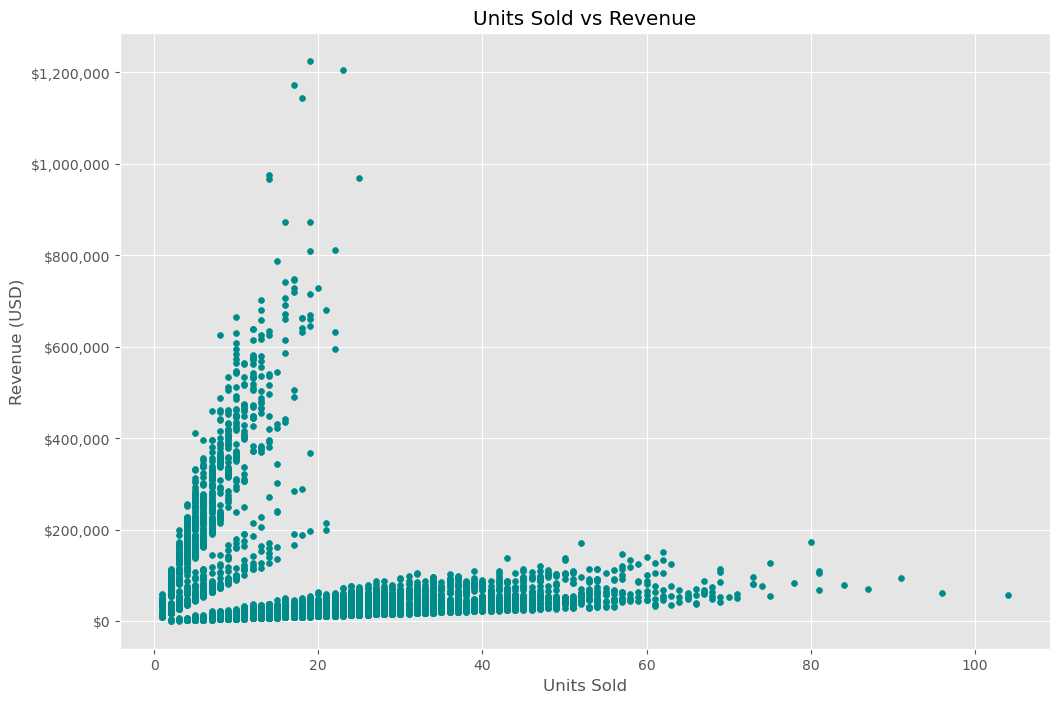

In [90]:
plt.scatter(df['units_sold'],
            df['revenue_usd'],
            s=18, 
            color='darkcyan'
           )

plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue (USD)')
format_currency()

plt.show()

### Results:
Revenue increases as Units Sold increases, showing positive correlation between the two.
Multiple visible clusters suggest that additional factors also affect Revenue, as well as the steepness of the gradients.
Amount of Units Sold does affect the Revenue.

### GPU Model vs Revenue

Do certain GPU Models generate higher Revenue?

Prediction: Certain GPU Models will generate higher Revenue.

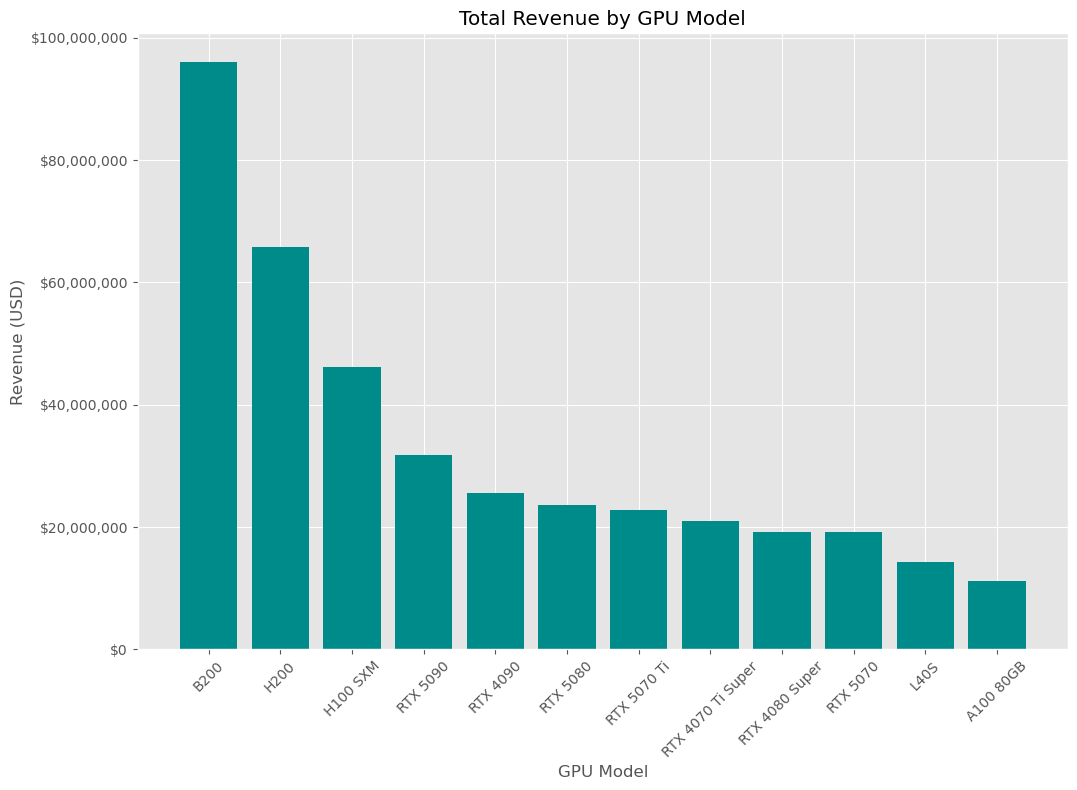

In [93]:
gpu_revenue = df.groupby('gpu_model')['revenue_usd'].sum().sort_values(ascending=False)

plt.bar(gpu_revenue.index,
        gpu_revenue.values,
        color='darkcyan'
       )

plt.title('Total Revenue by GPU Model')
plt.xlabel('GPU Model')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
format_currency()

plt.show()

### Results:
The majority of GPU Models generate about £200,000 in Revenue, however a minority generate substantially more Revenue than the rest.
Certain GPU Models do generate higher Revenue, especially 'B200'.

### Total Units Sold vs GPU Model

Are the results of certain GPU Models having high Revenue due to the amount of Units Sold of said GPU Models?

Prediction: Certain GPU Models will have higher Units Sold.

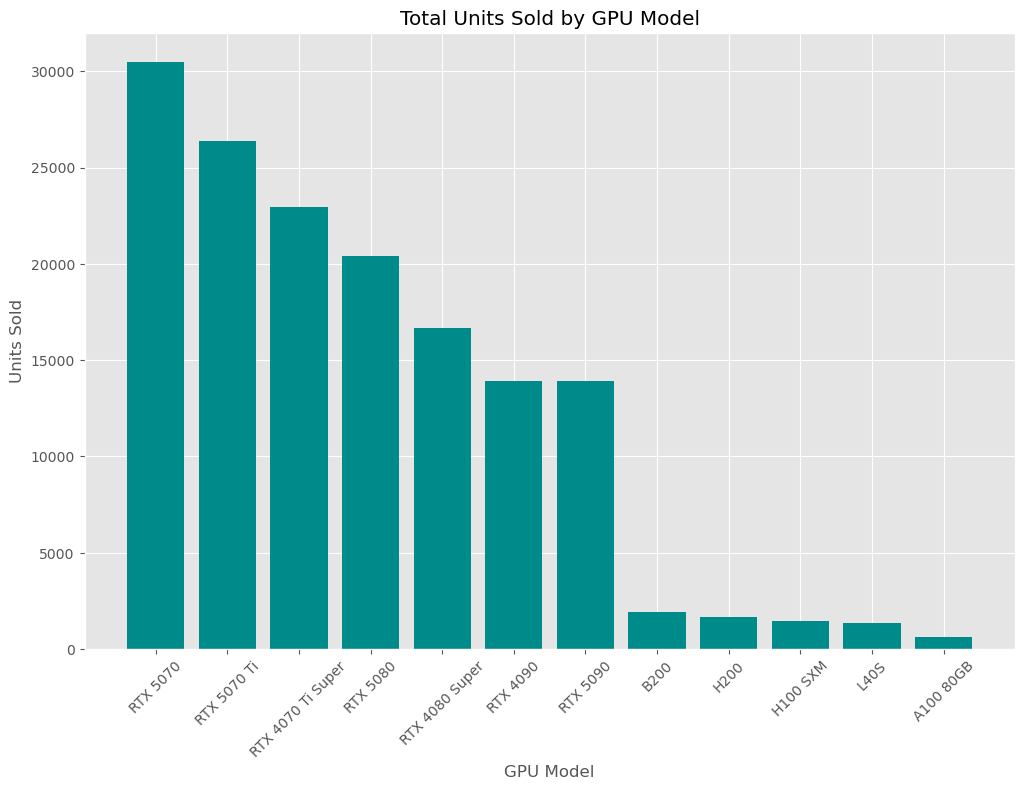

In [80]:
gpu_units = df.groupby('gpu_model')['units_sold'].sum().sort_values(ascending=False)

plt.bar(gpu_units.index,
        gpu_units.values,
        color='darkcyan'
       )

plt.title('Total Units Sold by GPU Model')
plt.xlabel('GPU Model')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)

plt.show()

### Results:
Certain GPU Models have incredibly little Units Sold, whilst the rest have alot of Units Sold.
However, not all GPU Models with substantial Units Sold generated high Revenues. 
The results of certain GPU Models having high Revenue are not due to the amount of Units Sold of said GPU Models.

### Region vs Revenue

Which Regions generate the highest Revenue?

Prediction: Certain regions will have higher Revenue.

C:\Users\Amanda\AppData\Local\Temp\ipykernel_7648\307785752.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_revenue = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)


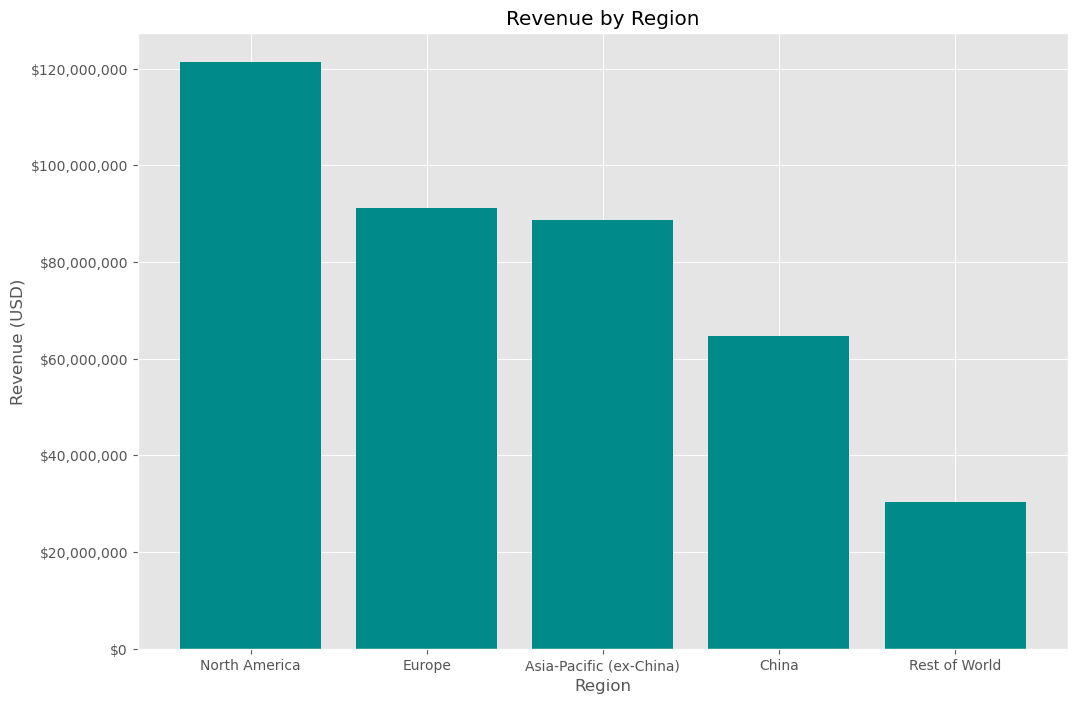

In [94]:
region_revenue = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)

plt.bar(region_revenue.index,
        region_revenue.values, 
        color='darkcyan'
       )

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue (USD)')
format_currency()

plt.show()

### Results:
North America has the highest Revenue, with Europe and Asia also generating high Revenue.

### Customer Segment vs Revenue

Which Customer Segments generate the highest Revenue?

Prediction: Certain Customer Segments will have higher Revenue.

C:\Users\Amanda\AppData\Local\Temp\ipykernel_7648\1591068621.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_revenue = df.groupby('customer_segment')['revenue_usd'].sum().sort_values(ascending=False)


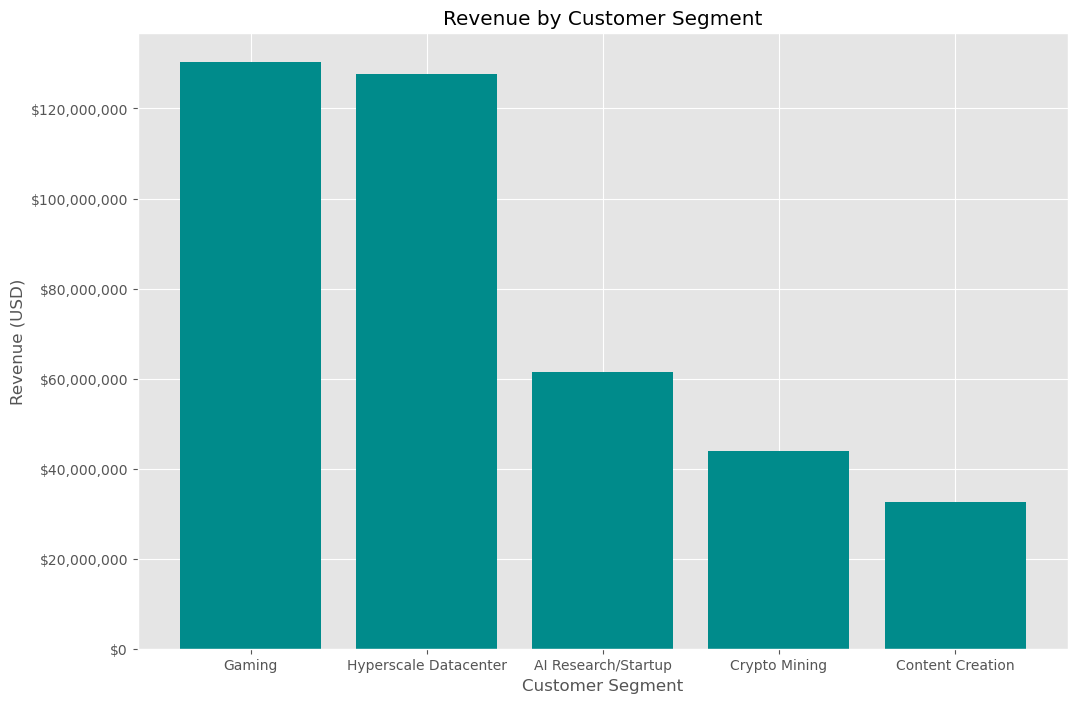

In [95]:
customer_revenue = df.groupby('customer_segment')['revenue_usd'].sum().sort_values(ascending=False)

plt.bar(customer_revenue.index,
        customer_revenue.values,
        color='darkcyan'
       )

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue (USD)')
format_currency()

plt.show()

### Results:
Gaming and Hyperscale Datacenters generate the highest Revenue.

### Sales Channel vs Revenue

Which Sales Channels generate the highest Revenue?

Prediction: Certain Sales Channels will have higher Revenue.

C:\Users\Amanda\AppData\Local\Temp\ipykernel_7648\1636385759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_revenue = df.groupby('sales_channel')['revenue_usd'].sum().sort_values(ascending=False)


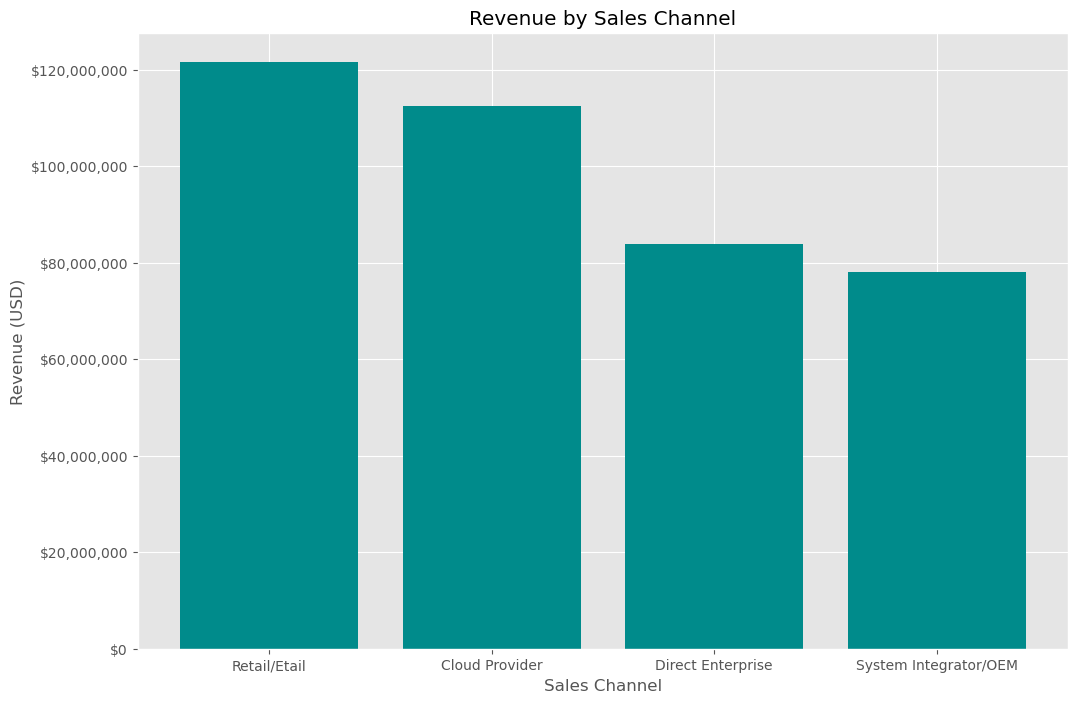

In [96]:
channel_revenue = df.groupby('sales_channel')['revenue_usd'].sum().sort_values(ascending=False)

plt.bar(channel_revenue.index,
        channel_revenue.values, 
        color='darkcyan'
       )

plt.title('Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue (USD)')
format_currency()

plt.show()

### Results:
Retail/Etail and Cloud Provider generate the highest Revenue

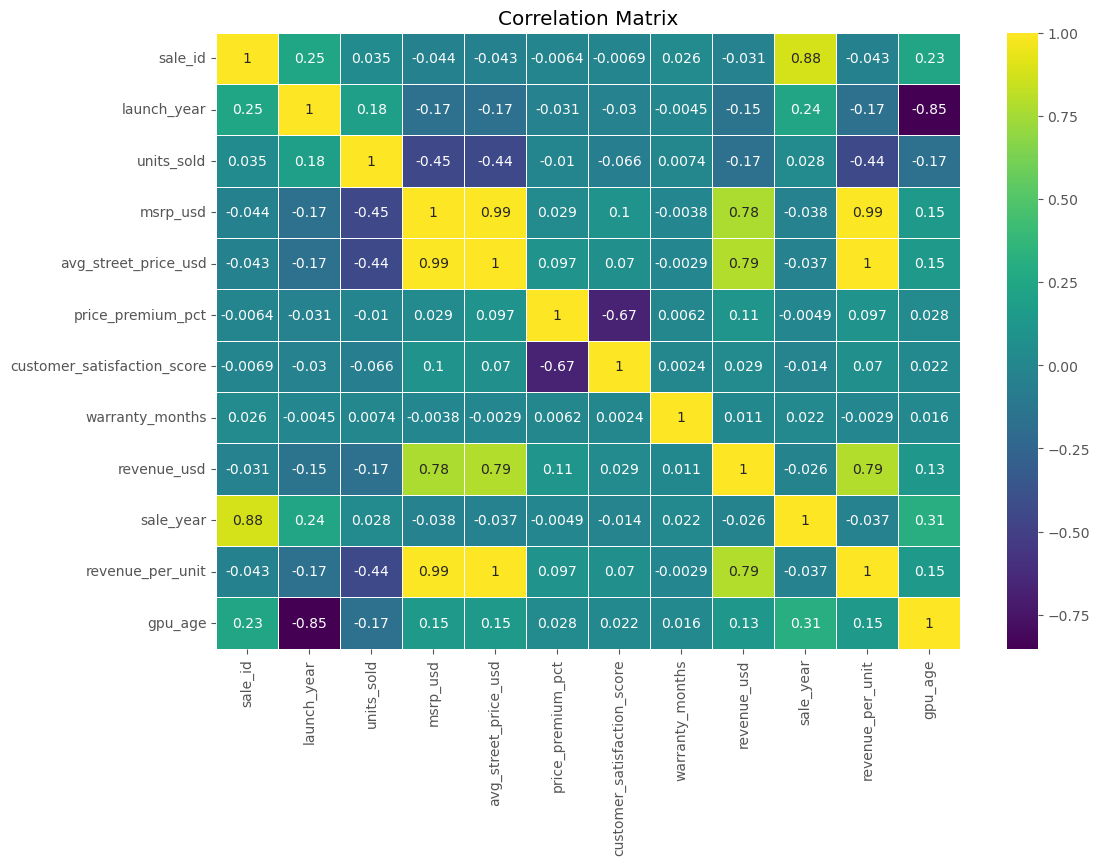

In [101]:
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='viridis',
            linewidths=0.5,
            linecolor='white'
           )

plt.title('Correlation Matrix')

plt.show()

In [85]:
top_5 = df.groupby('gpu_model')['revenue_usd'].sum().sort_values(ascending=False).head()

print(top_5)

gpu_model
B200        95930594.39
H200        65758987.10
H100 SXM    46083716.98
RTX 5090    31801505.82
RTX 4090    25550436.91
Name: revenue_usd, dtype: float64


# Conclusion
The analysis showed that units sold have a positive relationship with revenue, meaning products with higher sales volumes generally generate more revenue. However, the scatter plot showed several different clusters, suggesting that sales volume alone does not explain revenue differences. Other factors, such as product value, pricing and customer demand, also play an important role.

GPU model was one of the strongest factors affecting revenue. While many GPU models generated similar revenue levels, a small number performed significantly better. The B200 generated the highest revenue, followed by the H200, H100 SXM, RTX 5090 and RTX 4090. Interestingly, the GPUs generating the most revenue were not always the ones with the highest sales volume, showing that pricing and product demand also influence performance.

The regional analysis found that North America was the highest-revenue market, with Europe and Asia also making important contributions. Gaming and Hyperscale Datacenters were the strongest customer segments, while Retail/E-tail and Cloud Providers were the most valuable sales channels.

Overall, the analysis showed that revenue is influenced by several factors, including product type, region, customer segment and sales channel. Based on these findings, I would recommend that the business continues focusing on successful GPU models such as the B200 and H200 while investigating what makes these products perform well. I would also suggest exploring growth opportunities in Europe and Asia, and analysing additional information such as profit margins, pricing and customer behaviour to better understand what drives revenue.
